In [210]:
import os
import pandas as pd
from typing import List, Tuple
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import json
import torch
from cusum import CusumMeanDetector
from agent import DoubleDQNAgent

font = {'size': 16}

matplotlib.rc('font', **font)

In [211]:
DATASET_PATH = "../dataset"
INDEX_FIELD = "timestamp"
DATA_FIELD = "num_request"
CPD_CANDIDATE_ROOT = "../change_point_detection/offline_detection/cpd_candidate"
AGENT_STATE_DICT="../warm_up_selection/by_rl_window_size_transition/state_dict/"
N_LOOKBACK = 4
N_PREDICT = 2

DEVICE="cuda" if torch.cuda.is_available() else "cpu"

In [212]:
def get_data_file_list(dataset_path: str) -> List[str]:
    return os.listdir(dataset_path)

In [213]:
def read_dataset(csv_path: str,index_field:str,data_field:str) -> Tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(csv_path)
    return df[index_field].to_numpy(), df[data_field].to_numpy()

In [214]:
def read_candidate_cpds(path: str) -> List[int]:
    candidate_cpds = None
    with open(path, "r") as f:
        candidate_cpds = json.load(f)
    return candidate_cpds

In [215]:
def build_dataset(np_data: np.ndarray, candidate_cpds: List[int]):
    x = []
    y = []
    candidate_cpds = np.array(candidate_cpds, dtype=np.int32)
    np_data = np_data/20000.0
    for idx in range(len(np_data)-N_LOOKBACK-N_PREDICT+2):
        x.append(np_data[idx:idx+N_LOOKBACK+N_PREDICT-1].reshape((-1, 1)))
        is_less = candidate_cpds < idx+N_LOOKBACK+N_PREDICT
        future_candidate_idx = np.sum(is_less)
        if future_candidate_idx < len(candidate_cpds):
            nearest_cpd = candidate_cpds[future_candidate_idx]
            if nearest_cpd > idx + N_LOOKBACK+N_PREDICT+N_PREDICT:
                y.append(0)
            elif nearest_cpd >= idx + N_LOOKBACK+N_PREDICT:
                y.append(1)
            # else:
            #     y.append(2)
        else:
            y.append(0)
    # x = np.array(x)
    # y = np.array(y)
    return x, y

In [216]:
def ocpd(workload: np.ndarray, is_cpd_near_idx: List):
    change_idx = []
    t_max_warmup = 10
    cusum_detector = CusumMeanDetector(t_warmup=t_max_warmup, p_limit=0.05)
    cusum_detector.set_t_warmup(1)
    for idx, x in enumerate(workload):
        if not idx in is_cpd_near_idx:
            current_t_warmup = min(t_max_warmup, cusum_detector.get_t_warmup()+1)
            cusum_detector.set_t_warmup(current_t_warmup)
        _, is_change = cusum_detector.predict_next(torch.tensor(x,dtype=torch.float32))
        if is_change:
            cusum_detector.set_t_warmup(1)
            change_idx.append(idx)
    return change_idx

In [217]:
workload_to_skip_list = ["workload_1998-06-13", "workload_1998-06-14", "workload_1998-06-20", "workload_1998-06-21", "workload_1998-06-27", "workload_1998-06-28","workload_1998-07-04"]

read workload_1998-06-10.csv


/home/andrew/projects/autoscaling-k8s/ocpd/agent.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device)


read workload_1998-06-11.csv


/home/andrew/projects/autoscaling-k8s/ocpd/agent.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device)


read workload_1998-06-12.csv


...

/home/andrew/projects/autoscaling-k8s/ocpd/agent.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device)


read workload_1998-07-03.csv


/home/andrew/projects/autoscaling-k8s/ocpd/agent.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device)


read workload_1998-07-07.csv
read workload_1998-07-08.csv


/home/andrew/projects/autoscaling-k8s/ocpd/agent.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device)
/home/andrew/projects/autoscaling-k8s/ocpd/agent.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device)


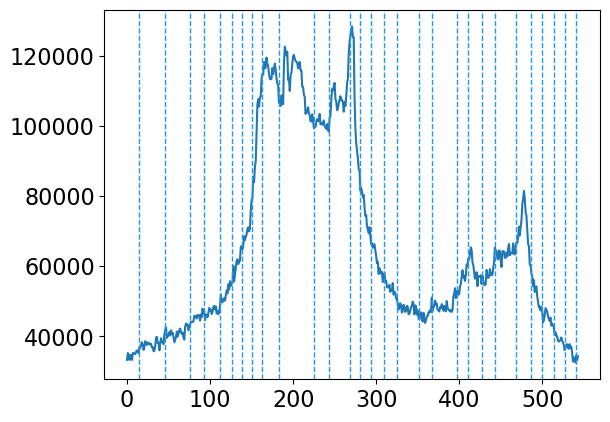

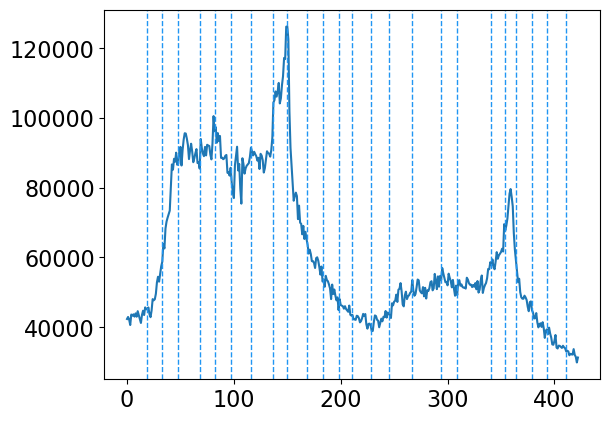

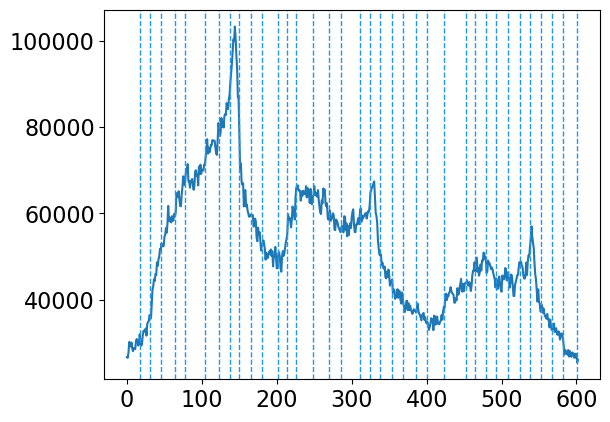

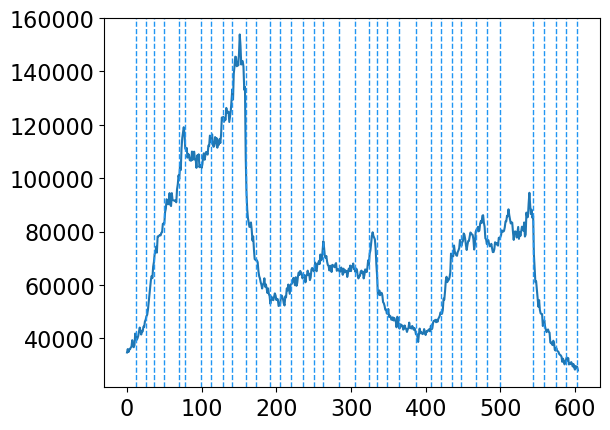

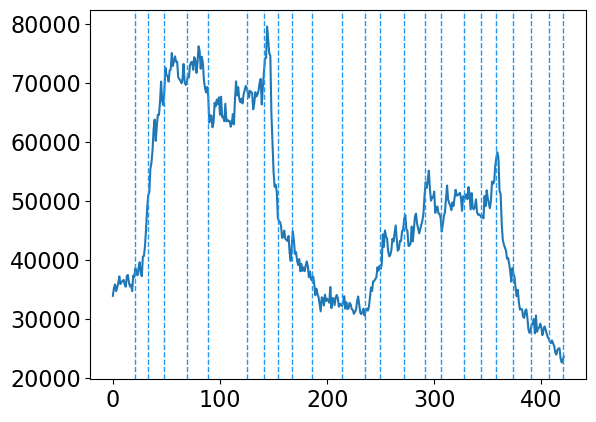

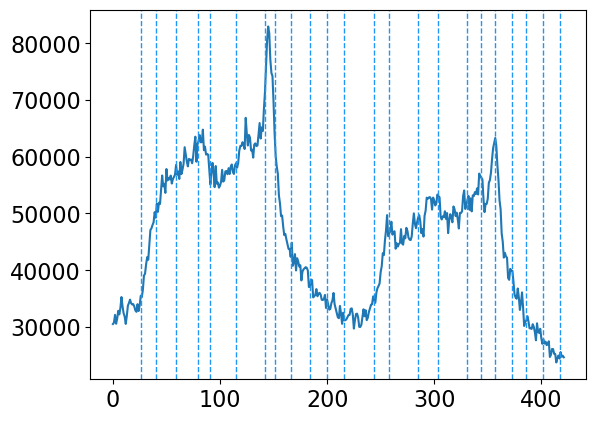

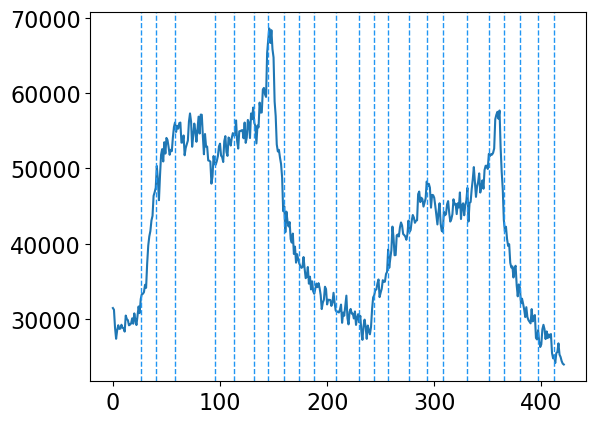

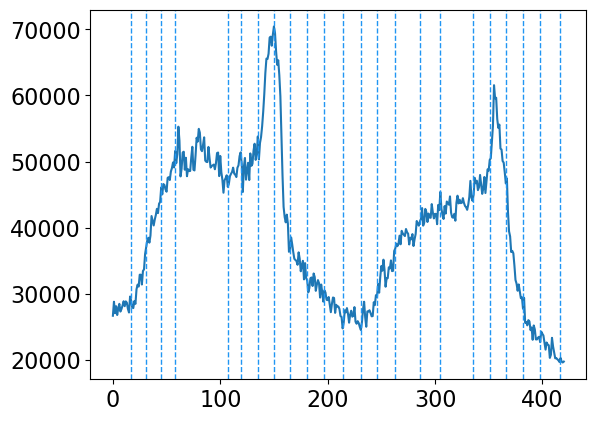

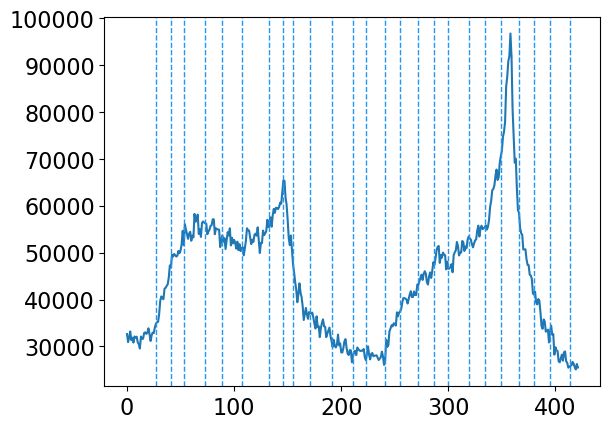

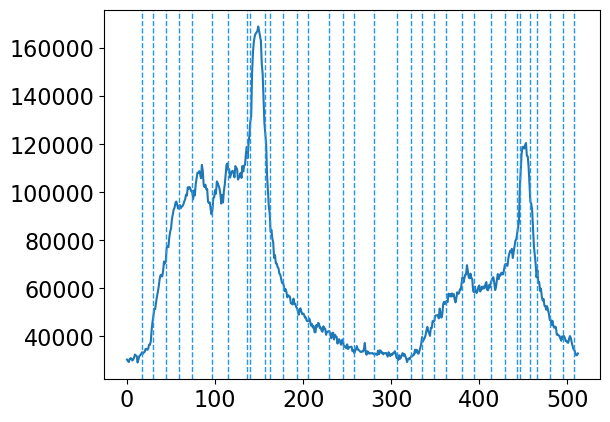

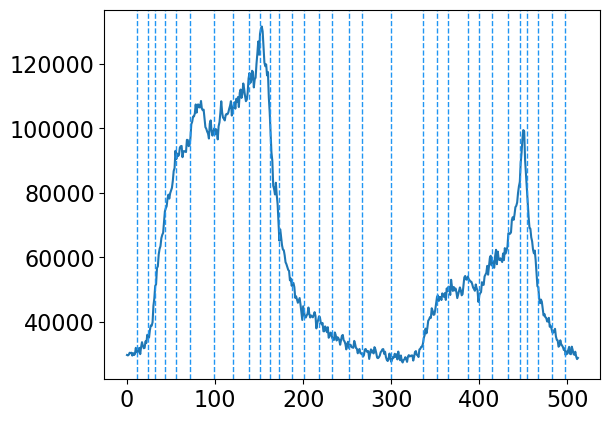

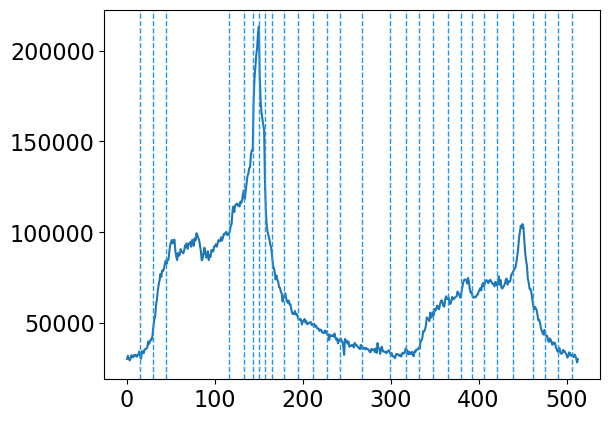

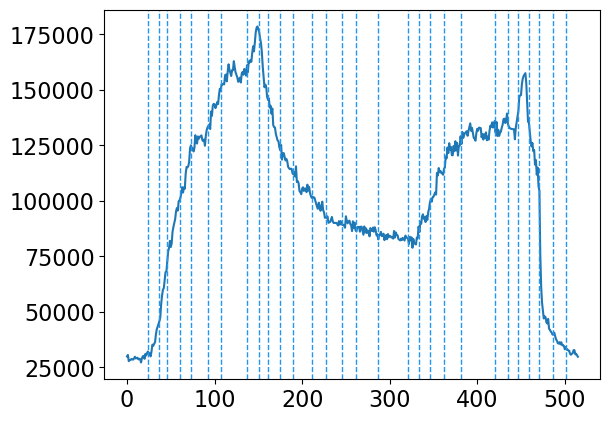

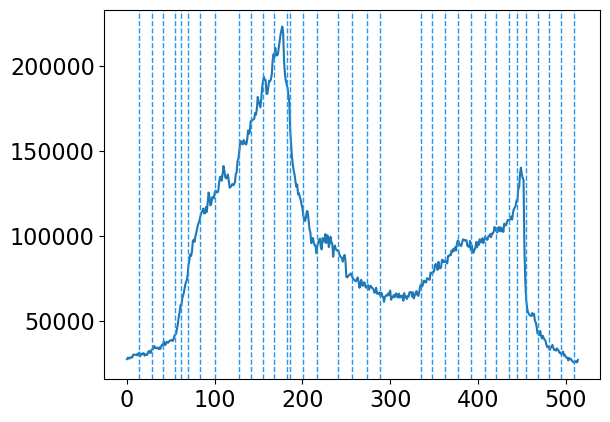

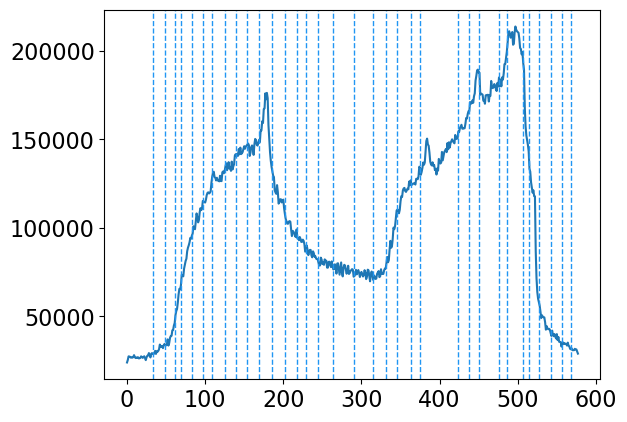

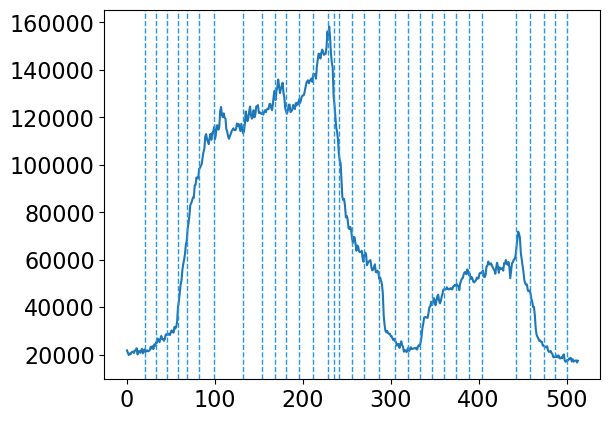

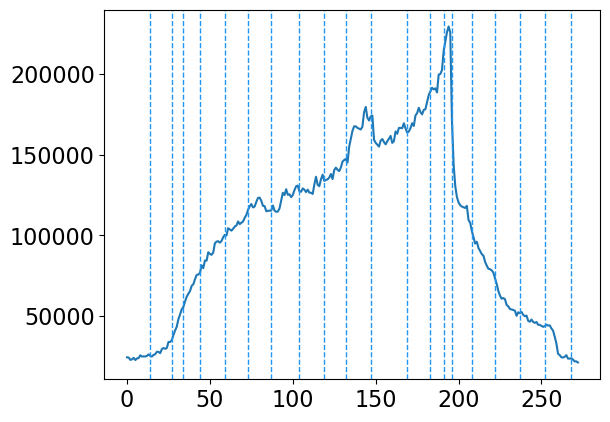

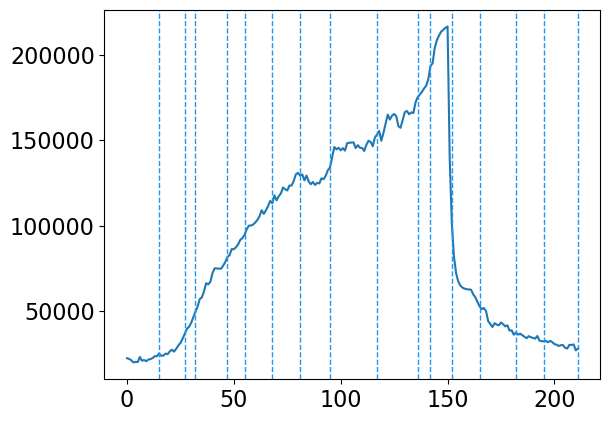

In [218]:
data_file_list = get_data_file_list(DATASET_PATH)
for file_name in data_file_list:
    workload_name = file_name.split(".")[0]
    if workload_name in workload_to_skip_list:
        continue
    print("read %s" % (file_name))
    np_index, np_data = read_dataset(os.path.join(DATASET_PATH, file_name), INDEX_FIELD, DATA_FIELD)
    workload_diff = np.diff(np_data).reshape((-1, 1))
    candidate_cpds = read_candidate_cpds(os.path.join(CPD_CANDIDATE_ROOT, workload_name+".json"))
    tx, ty = build_dataset(workload_diff, candidate_cpds)
    agent = DoubleDQNAgent(2)
    agent.load(AGENT_STATE_DICT+workload_name+".pth")
    agent.set_is_train(False)
    is_cpd_near = []
    for idx in range(len(tx)):
        x = tx[idx]
        x = torch.tensor(x, dtype=torch.float32).to(DEVICE)
        action = agent.take_action(x)
        is_cpd_near.append(action)
    pass
    is_cpd_near_idx = np.where(np.array(is_cpd_near) == 1)[0]+N_LOOKBACK
    ocpd_result = ocpd(np_data, is_cpd_near_idx)
    with open("result/"+workload_name+".json", "w") as f:
        json.dump(ocpd_result, f, indent=4)
    fig, ax = plt.subplots()
    cpds_pd = np.where(np.array(is_cpd_near) == 1)[0]+N_LOOKBACK
    ax.plot(np_data)
    # for cp in candidate_cpds:
    #     ax.axvline(x=cp, color="#4CAF50", linestyle='--', linewidth=1)
    # for cp in cpds_pd:
    #     ax.axvline(x=cp, color="#FF9800", linestyle='--', linewidth=1)
    for cp in ocpd_result:
        ax.axvline(x=cp, color="#2196F3", linestyle='--', linewidth=1)
    # break